In [17]:
import numpy as np
import matplotlib.pyplot as plt

In [26]:
A = np.array([
    [1, 0, 0, 0],
    [1, 15, 15**2, 15**3],
    [0, 1, 0, 0],
    [0, 1, 30, 675],
])
b_x = np.array([0, 5, 0, 0])
x_sol = np.linalg.solve(A, b_x)
for i, x in enumerate(x_sol):
    print(f"x_{i} = {x}")

x_0 = 0.0
x_1 = 0.0
x_2 = 0.06666666666666667
x_3 = -0.002962962962962963


In [27]:
b_y = np.array([0, 5, -0.5, -0.5])
y_sol = np.linalg.solve(A, b_y)
for i, y in enumerate(y_sol):
    print(f"y_{i} = {y}")

y_0 = 0.0
y_1 = -0.5000000000000002
y_2 = 0.16666666666666666
y_3 = -0.007407407407407407


In [33]:
def x(t):
    return x_sol[0] + x_sol[1] * t + x_sol[2] * t**2 + x_sol[3] * t**3

def y(t):
    return y_sol[0] + y_sol[1] * t + y_sol[2] * t**2 + y_sol[3] * t**3

def theta(t):
    return np.arctan2(y_sol[1] + 2 * y_sol[2] * t + 3 * y_sol[3] * t**2, x_sol[1] + 2 * x_sol[2] * t + 3 * x_sol[3] * t**2)

def v(t):
    return np.sqrt((x_sol[1] + 2 * x_sol[2] * t + 3 * x_sol[3] * t**2)**2 + (y_sol[1] + 2 * y_sol[2] * t + 3 * y_sol[3] * t**2)**2)


In [39]:
# make expressions for x_ddot and y_ddot
def x_ddot(t):
    return 2 * x_sol[2] + 6 * x_sol[3] * t

def y_ddot(t):
    return 2 * y_sol[2] + 6 * y_sol[3] * t

# get control inputs algebraically
def ctrl_inputs(t):
    A_ctrl = np.array([
        [np.cos(theta(t)), -v(t)*np.sin(theta(t))],
        [np.sin(theta(t)), v(t)*np.cos(theta(t))]
    ])

    accel_vec = np.array([x_ddot(t), y_ddot(t)])
    a, omega = np.linalg.solve(A_ctrl, accel_vec)
    return a, omega


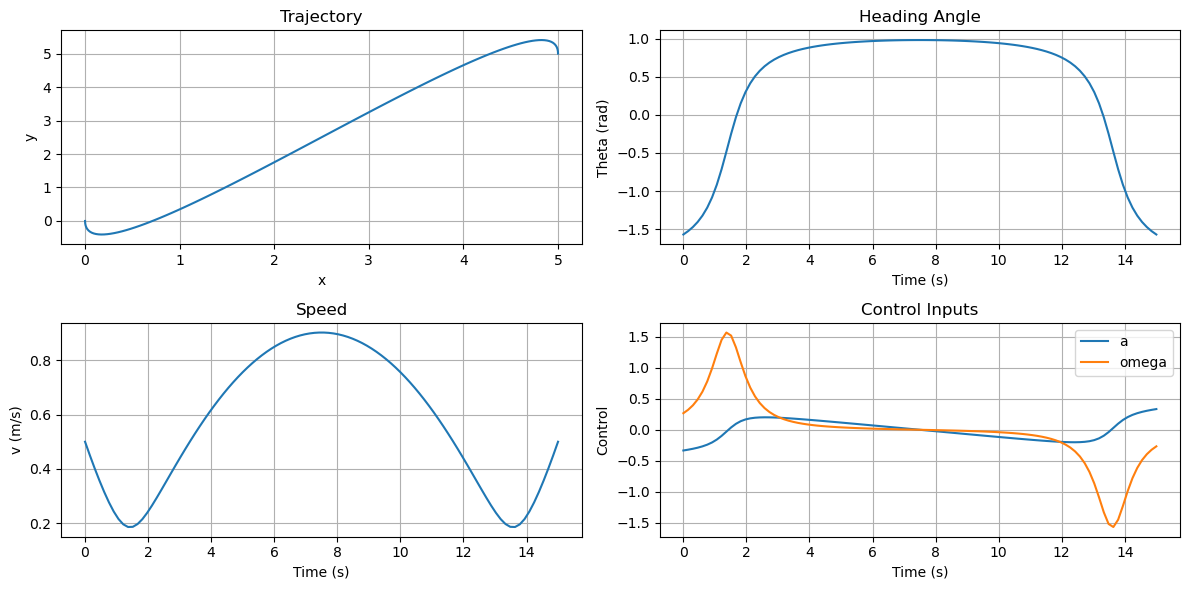

In [41]:
# plot the trajectory, heading angle, speed, and control inputs
t_vals = np.linspace(0, 15, 100)
ctrl_vals = np.array([ctrl_inputs(t) for t in t_vals])

plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.plot(x(t_vals), y(t_vals))
plt.title("Trajectory")
plt.xlabel("x")
plt.ylabel("y")

plt.subplot(2, 2, 2)
plt.plot(t_vals, theta(t_vals))
plt.title("Heading Angle")
plt.xlabel("Time (s)")
plt.ylabel("Theta (rad)")

plt.subplot(2, 2, 3)
plt.plot(t_vals, v(t_vals))
plt.title("Speed")
plt.xlabel("Time (s)")
plt.ylabel("v (m/s)")

plt.subplot(2, 2, 4)
plt.plot(t_vals, ctrl_vals[:, 0], label="a")
plt.plot(t_vals, ctrl_vals[:, 1], label="omega")
plt.title("Control Inputs")
plt.xlabel("Time (s)")
plt.ylabel("Control")
plt.legend()

for ax in plt.gcf().axes:
    ax.grid()

plt.tight_layout()
plt.show()
